In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="deep")

plt.rcParams.update({
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.6,
})

In [2]:
# Крок 1. Первинний аналіз даних
# Дані про кредити (South German Credit, 1970-ті). У файлі колонки з німецькими назвами,
# перейменовуємо їх на англійські (порядок беремо з опису датасету).
# Кожен рядок - один кредит, ознаки описують позичальника й умови кредиту.
cols = ["status", "duration", "credit_history", "purpose", "amount",
        "savings", "employment_duration", "installment_rate",
        "personal_status_sex", "other_debtors", "present_residence", "property",
        "age", "other_installment_plans", "housing", "number_credits",
        "job", "people_liable", "telephone", "foreign_worker", "credit_risk"]
df = pd.read_csv("SouthGermanCredit.asc", sep=r"\s+", header=0, names=cols)
df.shape

(1000, 21)

In [3]:
# Дивимось перші рядки. Майже всі колонки - цілі коди категорій (розшифровка є в codetable.txt), а
# числових по суті лише три: duration, amount, age.
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [4]:
# Типи, пропуски, дублікати
print(df.dtypes)
print()
print("пропусків:", df.isna().sum().sum())
print("дублікатів:", df.duplicated().sum())

status                     int64
duration                   int64
credit_history             int64
purpose                    int64
amount                     int64
savings                    int64
employment_duration        int64
installment_rate           int64
personal_status_sex        int64
other_debtors              int64
present_residence          int64
property                   int64
age                        int64
other_installment_plans    int64
housing                    int64
number_credits             int64
job                        int64
people_liable              int64
telephone                  int64
foreign_worker             int64
credit_risk                int64
dtype: object

пропусків: 0
дублікатів: 0


In [5]:
# Базова статистика по трьох числових ознаках
df[["duration", "amount", "age"]].describe()

,duration,amount,age
count,1000.000000,1000.00000,1000.00000
mean,20.903000,3271.24800,35.54200
std,12.058814,2822.75176,11.35267
min,4.000000,250.00000,19.00000
25%,12.000000,1365.50000,27.00000
50%,18.000000,2319.50000,33.00000
75%,24.000000,3972.25000,42.00000
max,72.000000,18424.00000,75.00000


In [6]:
# Баланс таргета credit_risk (0 - поганий кредит, 1 - добрий). Вибірка стратифікована, поганих взято
# більше, ніж у реальності: 700 добрих проти 300 поганих.
# Для кластеризації таргет не використовуємо (unsupervised), лишаємо його тільки для довідкової
# звірки в кінці.
df["credit_risk"].value_counts()

credit_risk
1    700
0    300
Name: count, dtype: int64

In [7]:
# Крок 2. Графічний аналіз
# Спочатку розкладемо ознаки по типах (за офіційним описом датасету) - це знадобиться і для
# графіків, і далі для кодування.
# Числові - справжні кількісні; порядкові - коди з осмисленим порядком; номінальні - коди без
# порядку (число лише мітка); бінарні - дві категорії.
numeric = ["duration", "amount", "age"]
ordinal = ["employment_duration", "installment_rate", "present_residence",
           "property", "number_credits", "job"]
nominal = ["status", "credit_history", "purpose", "savings",
           "personal_status_sex", "other_debtors", "other_installment_plans",
           "housing"]
binary = ["people_liable", "telephone", "foreign_worker"]
len(numeric), len(ordinal), len(nominal), len(binary)

(3, 6, 8, 3)

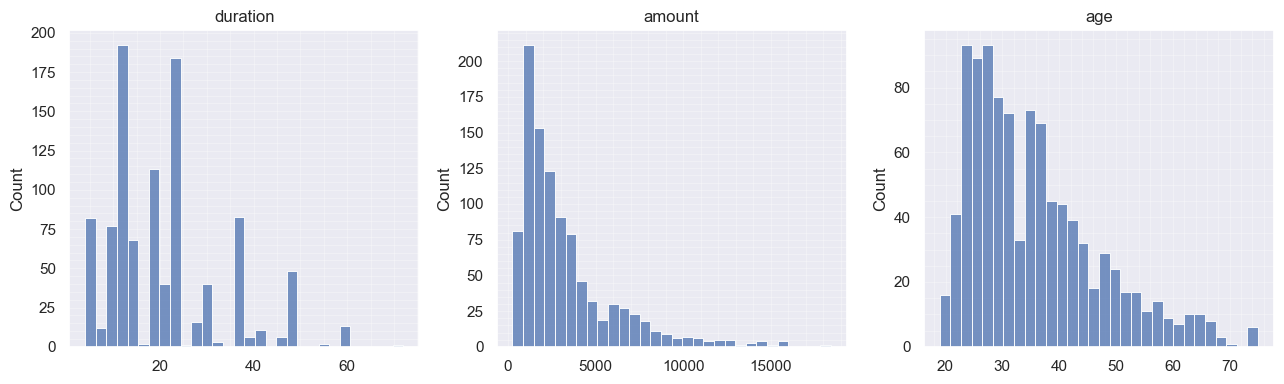

In [8]:
# Розподіли трьох числових ознак. duration і amount помітно скошені вправо (більшість кредитів
# короткі й невеликі, є довгий хвіст великих сум), age зміщений до молодших позичальників.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, numeric):
    sns.histplot(df[col], bins=30, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

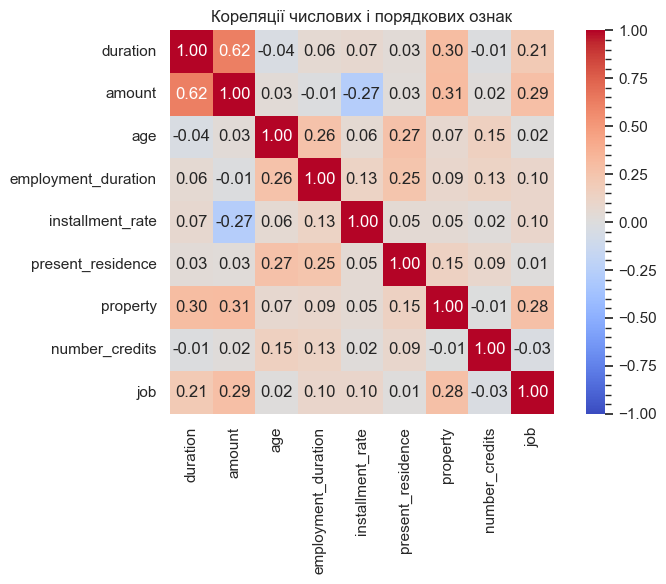

In [9]:
# Кореляції числових і порядкових ознак (номінальні сюди не беремо - там число без порядку).
# Найпомітніший звʼязок duration з amount (довші кредити - більші суми), решта звʼязків слабкі.
corr = df[numeric + ordinal].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Кореляції числових і порядкових ознак")
plt.tight_layout()
plt.show()

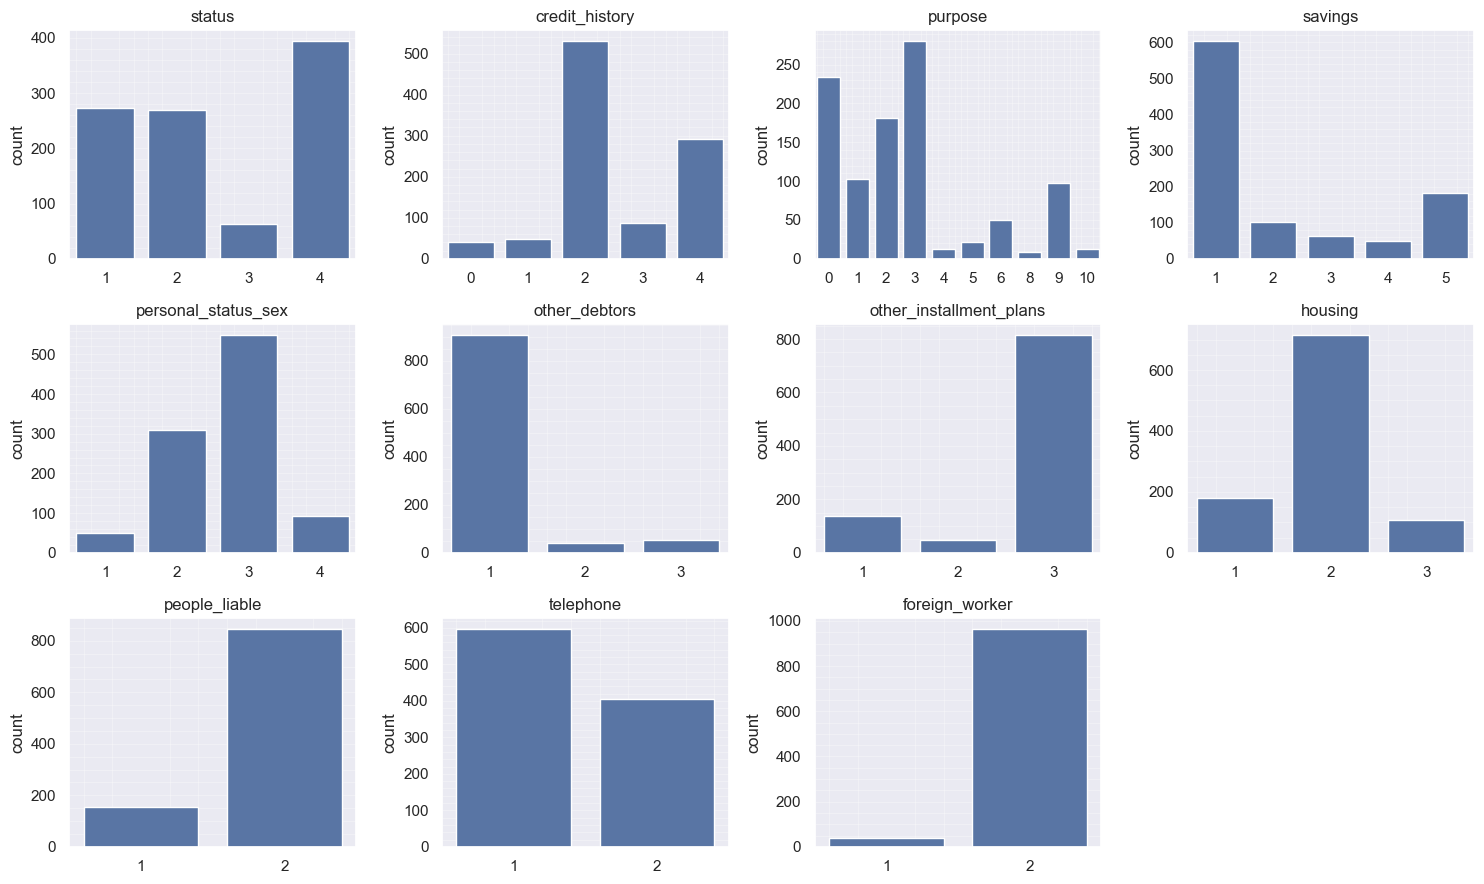

In [10]:
# Розподіли категоріальних ознак (номінальні + бінарні). Видно, що частина категорій сильно
# переважає (наприклад, більшість - місцеві не-іноземці, без інших боржників), а деякі значення
# рідкісні.
cat_cols = nominal + binary
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.countplot(x=df[col], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
for ax in axes.ravel()[len(cat_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

In [11]:
# Крок 3. Кодування і масштабування
# Числові й порядкові ознаки лишаємо числами і стандартизуємо. Спершу amount і duration логарифмуємо
# (log1p), бо вони сильно скошені вправо і кілька дуже великих кредитів мали б завелику вагу.
# Номінальні й бінарні коди розбиваємо на 0/1 колонки (one-hot), щоб відстань не сприймала код 10 як
# "далекий" від коду 1. Ці 0/1 колонки не стандартизуємо, щоб рідкісні категорії не отримали
# завеликих значень.
df_enc = df.copy()
df_enc["amount"] = np.log1p(df_enc["amount"])
df_enc["duration"] = np.log1p(df_enc["duration"])

scaler = StandardScaler()
X_num = pd.DataFrame(scaler.fit_transform(df_enc[numeric + ordinal]),
                     columns=numeric + ordinal, index=df.index)
X_cat = pd.get_dummies(df[nominal + binary], columns=nominal + binary,
                       prefix=nominal + binary).astype(int)
X = pd.concat([X_num, X_cat], axis=1)
X.shape

(1000, 52)

In [12]:
# Після кодування замість 20 ознак маємо 52 колонки (номінальні розгорнулись у окремі індикатори).
# Це багатовимірний простір, який далі спробуємо стиснути через PCA. Дивимось кілька колонок для
# перевірки.
X.iloc[:3, list(range(4)) + list(range(9, 13))]

,duration,amount,age,employment_duration,status_1,status_2,status_3,status_4
0,0.006404,-1.073423,-1.281573,-1.145978,1,0,0,0
1,-1.168929,0.190985,0.040363,-0.317959,1,0,0,0
2,-0.688500,-1.358017,-1.105315,0.510060,0,1,0,0


In [13]:
# Крок 4. Кластеризація на повному датасеті
# Беремо дві моделі - k-Means і Agglomerative - і для кожної кількості кластерів рахуємо дві
# метрики: silhouette (наскільки об'єкти лежать у своїх кластерах, більше - краще) і Calinski-
# Harabasz (відношення міжкластерного розкиду до внутрішнього, теж більше - краще).
# Так підберемо оптимальну кількість кластерів.
def cluster_scores(data, k_range):
    rows = []
    for name, model_cls in [("k-Means", KMeans), ("Agglomerative", AgglomerativeClustering)]:
        for k in k_range:
            model = KMeans(n_clusters=k, random_state=42, n_init=10) if name == "k-Means" \
                    else AgglomerativeClustering(n_clusters=k)
            labels = model.fit_predict(data)
            rows.append({"model": name, "k": k,
                         "silhouette": silhouette_score(data, labels),
                         "calinski": calinski_harabasz_score(data, labels)})
    return pd.DataFrame(rows)

k_range = range(2, 11)
scores_full = cluster_scores(X, k_range)
scores_full.round(3)

,model,k,silhouette,calinski
0,k-Means,2,0.099,120.781
1,k-Means,3,0.090,99.532
2,k-Means,4,0.075,83.060
3,k-Means,5,0.071,73.809
4,k-Means,6,0.068,66.364
5,k-Means,7,0.070,61.168
6,k-Means,8,0.065,56.089
7,k-Means,9,0.072,52.772
8,k-Means,10,0.060,49.083
9,Agglomerative,2,0.072,81.411


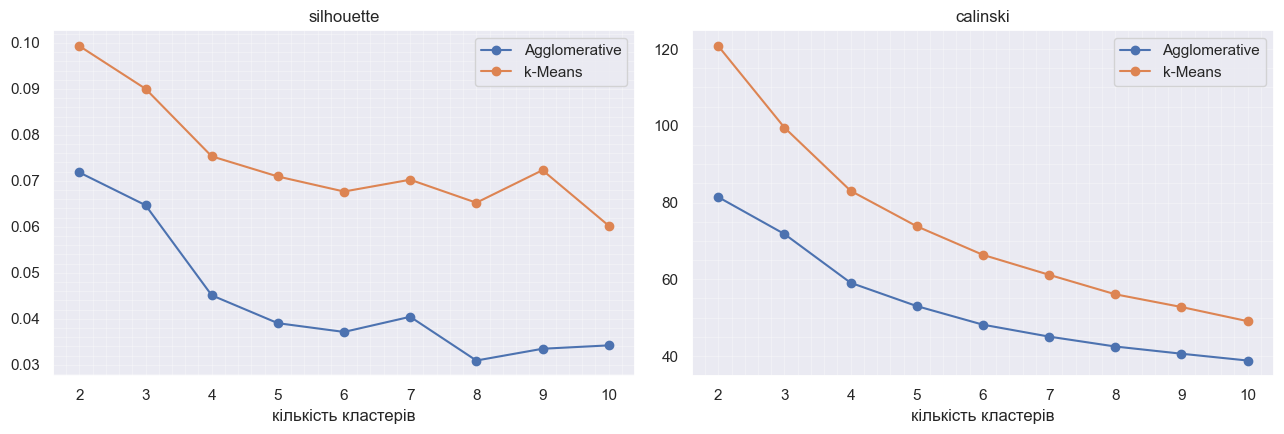

In [14]:
# Малюємо обидві метрики по кількості кластерів для обох моделей. Дивимось, де метрики найкращі -
# там і оптимальна кількість кластерів.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for metric, ax in zip(["silhouette", "calinski"], axes):
    for name, grp in scores_full.groupby("model"):
        ax.plot(grp["k"], grp[metric], marker="o", label=name)
    ax.set_title(metric)
    ax.set_xlabel("кількість кластерів")
    ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# Обидві метрики для обох моделей найкращі при 2 кластерах, далі спадають. Тобто на повному датасеті
# оптимальний поділ - на 2.
# Значення silhouette низькі (близько 0.1) - виражених груп у даних мало. Фіксуємо розбиття на 2
# (k-Means), воно знадобиться для порівняння з PCA-розбиттям.
best_k_full = 2
km_full = KMeans(n_clusters=best_k_full, random_state=42, n_init=10).fit(X)
labels_full = km_full.labels_
pd.Series(labels_full).value_counts().sort_index()

0    509
1    491
Name: count, dtype: int64

In [16]:
# Подивимось, чим відрізняються два кластери: беремо середні сирі значення ключових ознак і
# найбільші розриви між центрами кластерів.
# Поділ іде за розміром і строком кредиту: один кластер - невеликі короткі кредити, інший - великі
# довгі.
# Найбільші розриви - у числових і порядкових ознак (duration, amount, property, job), а
# категоріальні 0/1 колонки на поділ майже не впливають.
profile = df.assign(cluster=labels_full).groupby("cluster")[numeric].mean().round(0)
top_sep = (pd.Series(km_full.cluster_centers_[0] - km_full.cluster_centers_[1],
                     index=X.columns).abs().sort_values(ascending=False).head(6))
print("середні сирі значення по кластерах:")
print(profile.to_string())
print("\nнайбільші розриви між центрами кластерів:")
print(top_sep.round(2).to_string())

середні сирі значення по кластерах:
         duration  amount   age
cluster                        
0            14.0  1684.0  35.0
1            29.0  4916.0  37.0

найбільші розриви між центрами кластерів:
amount               1.33
duration             1.29
property             1.05
job                  0.83
present_residence    0.38
telephone_1          0.37


In [17]:
# Довідково: чи не збіглись кластери з кредитним ризиком? Ні - ARI близький до нуля.
# Кластери групують кредити за розміром і строком, а не за добрі/погані - таргет вони не бачили.
print("ARI(кластери, credit_risk):", round(adjusted_rand_score(labels_full, df["credit_risk"]), 3))
pd.crosstab(labels_full, df["credit_risk"], rownames=["кластер"], colnames=["credit_risk"])

ARI(кластери, credit_risk): 0.004


credit_risk,0,1
кластер,,
0,137,372
1,163,328


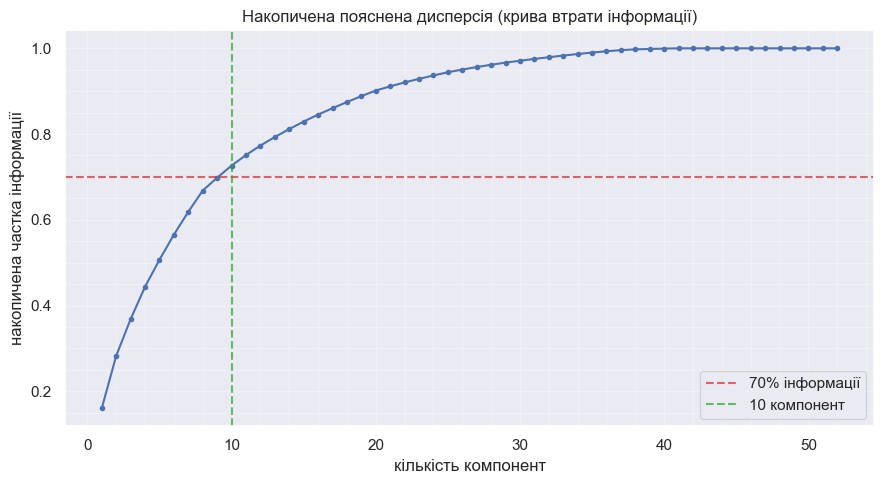

In [18]:
# Крок 5. Зменшення розмірності через PCA
# PCA будує нові осі вздовж найбільшого розкиду даних. Поле explained_variance_ratio_ каже, яку
# частку інформації несе кожна компонента.
# Малюємо накопичену суму - за нею видно, скільки компонент треба, щоб лишити 70% інформації (тобто
# свідомо втратити 30%).
pca_full = PCA().fit(X)
cum = np.cumsum(pca_full.explained_variance_ratio_)
n_70 = int(np.argmax(cum >= 0.70) + 1)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cum) + 1), cum, marker="o", ms=3)
plt.axhline(0.70, color="tab:red", ls="--", alpha=0.7, label="70% інформації")
plt.axvline(n_70, color="tab:green", ls="--", alpha=0.7, label=f"{n_70} компонент")
plt.title("Накопичена пояснена дисперсія (крива втрати інформації)")
plt.xlabel("кількість компонент")
plt.ylabel("накопичена частка інформації")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Щоб зберегти 70% інформації, достатньо n_70 компонент замість 52 колонок. Перетворюємо датасет
# саме в стільки компонент - це наш стиснений датасет, на якому далі повторимо кластеризацію.
print(f"компонент для 70% інформації: {n_70} (з {X.shape[1]})")
print(f"фактично збережено інформації: {cum[n_70 - 1]:.3f}")
X_pca = PCA(n_components=n_70, random_state=42).fit_transform(X)
X_pca.shape

компонент для 70% інформації: 10 (з 52)
фактично збережено інформації: 0.726


(1000, 10)

In [20]:
# Крок 6. Кластеризація на перетвореному датасеті
# Повторюємо ту саму процедуру, що й на повному датасеті, але тепер на PCA-компонентах: ті самі дві
# моделі, ті самі дві метрики, ті самі k.
scores_pca = cluster_scores(X_pca, k_range)
scores_pca.round(3)

,model,k,silhouette,calinski
0,k-Means,2,0.137,173.924
1,k-Means,3,0.128,147.509
2,k-Means,4,0.111,125.577
3,k-Means,5,0.108,113.428
4,k-Means,6,0.108,102.979
5,k-Means,7,0.109,96.656
6,k-Means,8,0.110,90.945
7,k-Means,9,0.106,85.729
8,k-Means,10,0.113,82.237
9,Agglomerative,2,0.103,115.007


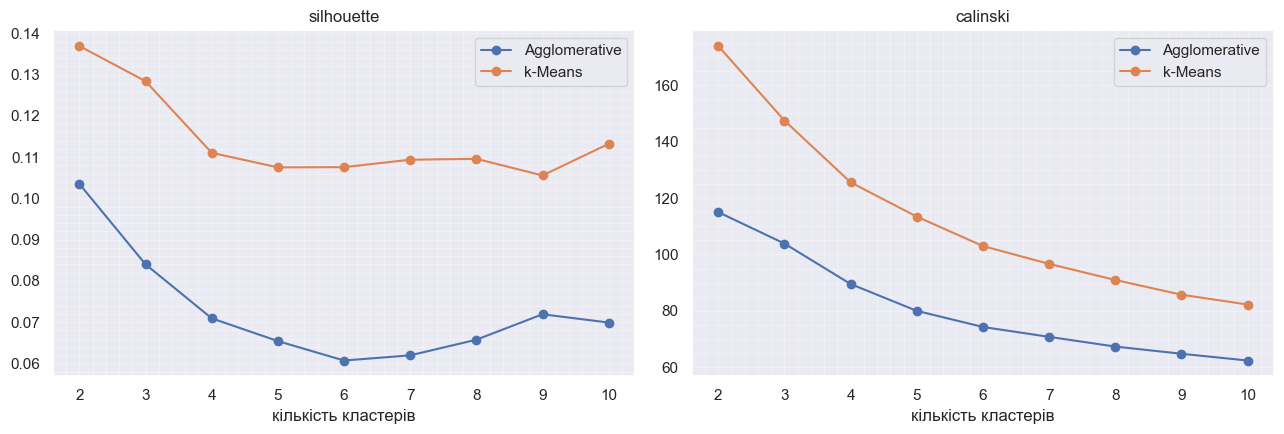

In [21]:
# Метрики по кількості кластерів на PCA-датасеті. Порівнюємо форму кривих із тим, що було на повному
# датасеті.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for metric, ax in zip(["silhouette", "calinski"], axes):
    for name, grp in scores_pca.groupby("model"):
        ax.plot(grp["k"], grp[metric], marker="o", label=name)
    ax.set_title(metric)
    ax.set_xlabel("кількість кластерів")
    ax.legend()
plt.tight_layout()
plt.show()

In [22]:
# Картина та сама, що й на повному датасеті: оптимальна кількість кластерів - 2. silhouette тут
# навіть трохи вищий (близько 0.14 проти 0.10).
# Фіксуємо розбиття на 2 (k-Means) на PCA-датасеті для порівняння з повним.
best_k_pca = 2
labels_pca = KMeans(n_clusters=best_k_pca, random_state=42, n_init=10).fit_predict(X_pca)
pd.Series(labels_pca).value_counts().sort_index()

0    507
1    493
Name: count, dtype: int64

In [23]:
# Крок 7. Порівняння розбиттів: повний датасет проти PCA
# Кластери - це просто номери, тому напряму мітки з двох розбиттів не збігаються. Будуємо таблицю
# перетинів: скільки об'єктів з кожного кластера на повному датасеті потрапило в кожен кластер на
# PCA-датасеті.
# Якщо групи ті самі, майже всі об'єкти зберуться у двох клітинках таблиці.
ct = pd.crosstab(labels_full, labels_pca, rownames=["повний"], colnames=["PCA"])
ct

PCA,0,1
повний,,
0,507,2
1,0,491


In [24]:
# Рахуємо узгодженість двох розбиттів. Номери кластерів довільні, тому підбираємо їх відповідність
# так, щоб збіг був максимальним, і дивимось частку об'єктів, що лишились у "тій самій" групі.
# ARI - окрема міра схожості двох розбиттів (1 - ідентичні, близько 0 - випадковий збіг).
n = len(labels_full)
agree = max(np.trace(ct.values), np.trace(np.fliplr(ct.values))) / n
print(f"однаково згруповано: {agree:.3f}")
print(f"ARI повний vs PCA: {adjusted_rand_score(labels_full, labels_pca):.3f}")

однаково згруповано: 0.998
ARI повний vs PCA: 0.992


In [25]:
# Висновки
# - Дані - 1000 кредитів, майже все категоріальне. Після кодування (log для amount/duration,
#   стандартизація числових і порядкових, one-hot для решти) вийшло 52 колонки.
# - На повному датасеті обидві моделі й обидві метрики дали 2 кластери (silhouette низький ~0.1).
#   Кластери діляться за розміром і строком кредиту, з кредитним ризиком не збігаються (ARI ~0).
# - PCA: для 70% інформації вистачило 10 компонент замість 52 - стиснення в ~5 разів.
# - На стисненому датасеті - ті самі 2 кластери, розбиття майже збіглось з повним (ARI ~0.99). Тобто
#   після втрати 30% інформації кластеризація майже не змінилась.